<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-attack-risk-ml-100?scriptVersionId=236893184" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-risk-assessment-dataset/Heart_Attack_Risk_Levels_Dataset.csv


## Title: 
Heart Attack Risk Dataset

## Description: 
Dataset containing clinical and lifestyle attributes to assess an individual's risk of heart attack, including age, cholesterol levels, blood pressure, and more.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/heart-attack-risk-assessment-dataset/Heart_Attack_Risk_Levels_Dataset.csv')

In [3]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,negative,Moderate,Monitor closely and consult doctor
1,20,1,94,98,46,296.0,6.75,1.060,positive,High,Immediate medical attention
2,56,1,64,160,77,270.0,1.99,0.003,negative,Moderate,Monitor closely and consult doctor
3,66,1,70,120,55,270.0,13.87,0.122,positive,High,Immediate medical attention
4,54,1,64,112,65,300.0,1.08,0.003,negative,Moderate,Monitor closely and consult doctor


In [4]:
df.tail()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
1314,44,1,94,122,67,204.0,1.63,0.006,negative,Moderate,Monitor closely and consult doctor
1315,66,1,84,125,55,149.0,1.33,0.172,positive,High,Immediate medical attention
1316,45,1,85,168,104,96.0,1.24,4.250,positive,High,Immediate medical attention
1317,54,1,58,117,68,443.0,5.80,0.359,positive,High,Immediate medical attention
1318,51,1,94,157,79,134.0,50.89,1.770,positive,High,Immediate medical attention


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
 9   Risk_Level                1319 non-null   object 
 10  Recommendation            1319 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 113.5+ KB


In [6]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.193328,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.638173,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [7]:
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
Risk_Level                  0
Recommendation              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(1319, 11)

In [10]:
df.dtypes

Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
Risk_Level                   object
Recommendation               object
dtype: object

In [11]:
df.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result', 'Risk_Level', 'Recommendation'],
      dtype='object')

## Data visualizations

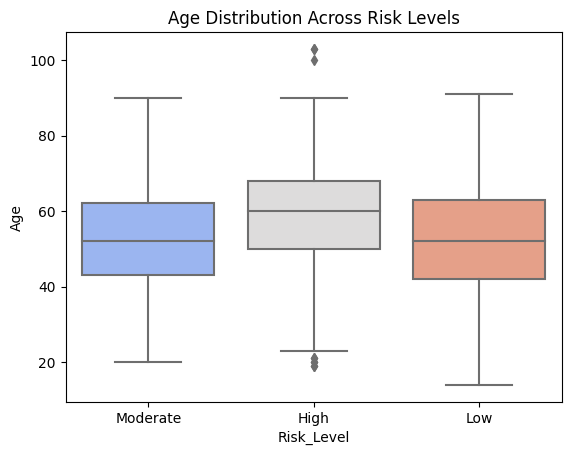

In [12]:
sns.boxplot(data=df, x='Risk_Level', y='Age', palette='coolwarm')
plt.title('Age Distribution Across Risk Levels')
plt.show()

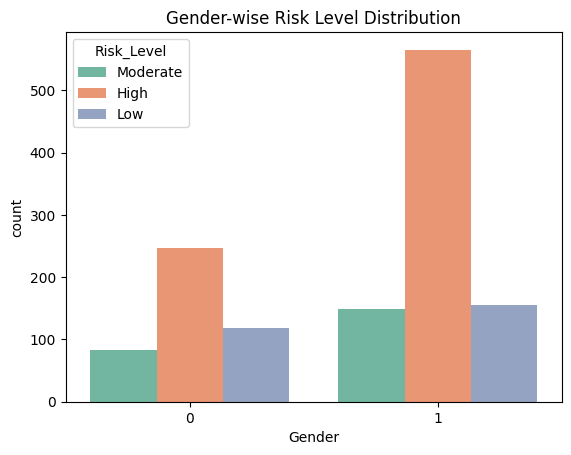

In [13]:
sns.countplot(data=df, x='Gender', hue='Risk_Level', palette='Set2')
plt.title('Gender-wise Risk Level Distribution')
plt.show()


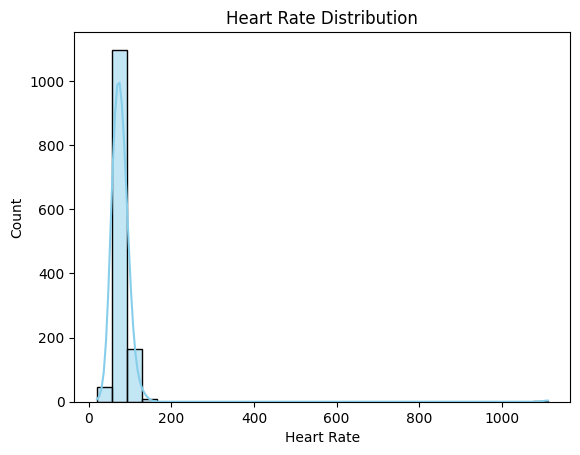

In [14]:
sns.histplot(df['Heart rate'], kde=True, bins=30, color='skyblue')
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate')
plt.show()


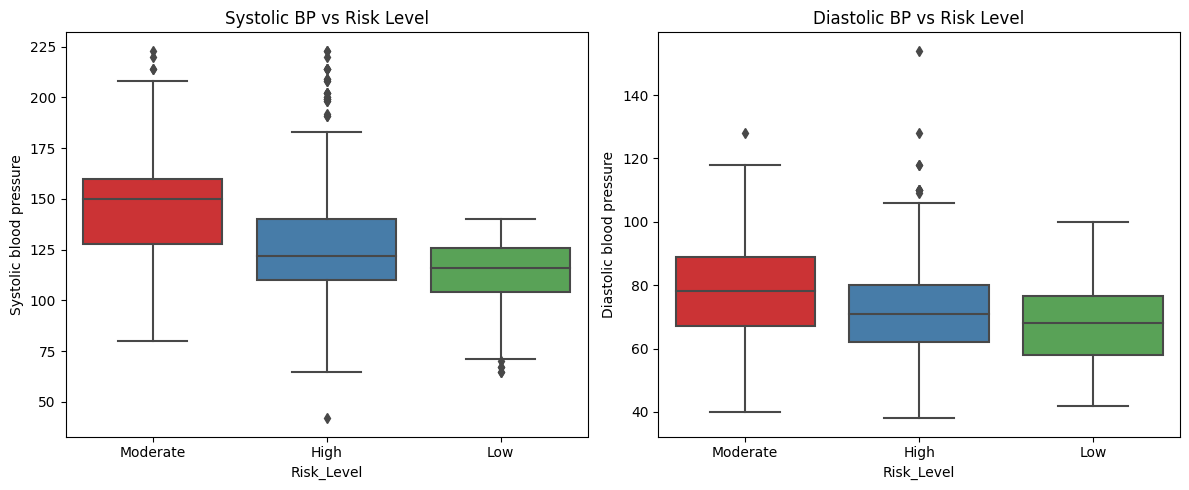

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Risk_Level', y='Systolic blood pressure', ax=axes[0], palette='Set1')
axes[0].set_title('Systolic BP vs Risk Level')

sns.boxplot(data=df, x='Risk_Level', y='Diastolic blood pressure', ax=axes[1], palette='Set1')
axes[1].set_title('Diastolic BP vs Risk Level')

plt.tight_layout()
plt.show()


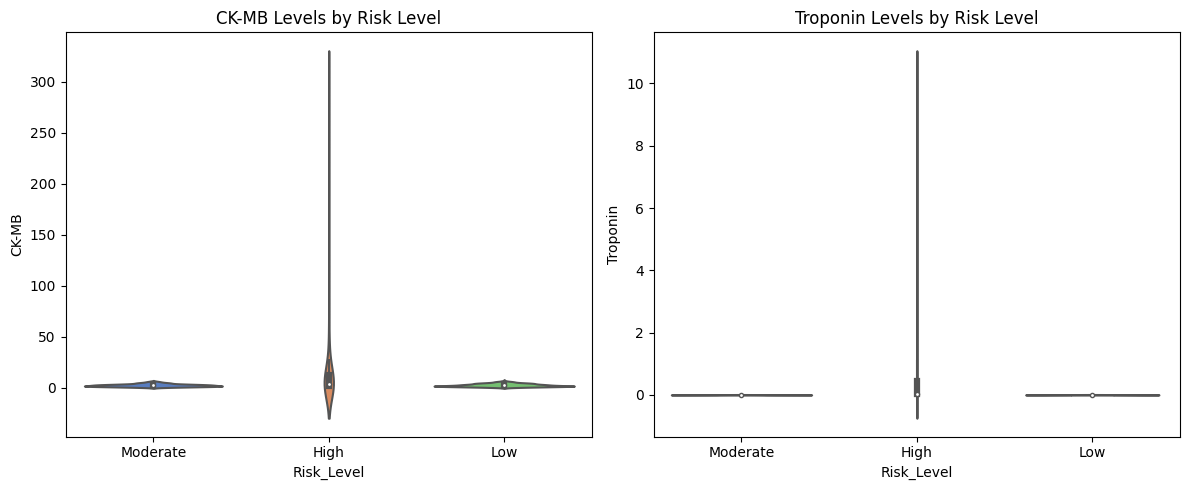

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df, x='Risk_Level', y='CK-MB', ax=axes[0], palette='muted')
axes[0].set_title('CK-MB Levels by Risk Level')

sns.violinplot(data=df, x='Risk_Level', y='Troponin', ax=axes[1], palette='muted')
axes[1].set_title('Troponin Levels by Risk Level')

plt.tight_layout()
plt.show()


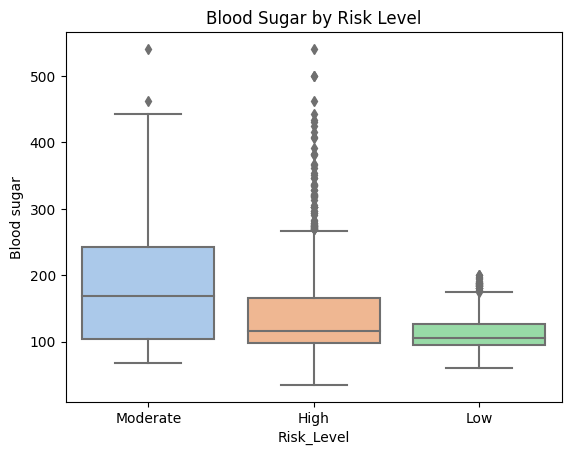

In [17]:
sns.boxplot(data=df, x='Risk_Level', y='Blood sugar', palette='pastel')
plt.title('Blood Sugar by Risk Level')
plt.show()


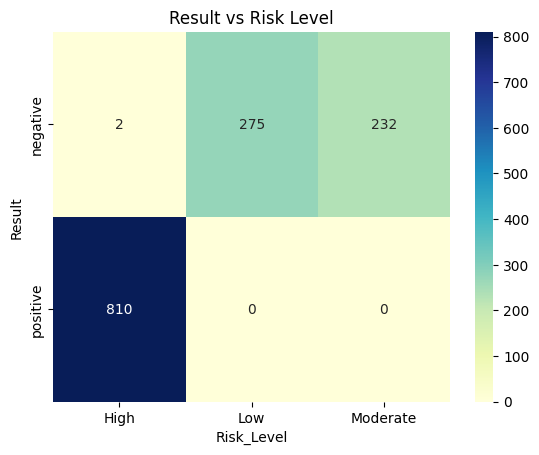

In [18]:
cross_tab = pd.crosstab(df['Result'], df['Risk_Level'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Result vs Risk Level')
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
# Drop "Recommendation" (not useful for training)
df = df.drop(columns=['Recommendation'])

# Label Encoding for categorical columns
le = LabelEncoder()
for col in ['Gender', 'Result', 'Risk_Level']:
    df[col] = le.fit_transform(df[col])

In [21]:
# Features and Target
X = df.drop(columns=['Risk_Level'])
y = df['Risk_Level']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}


🔹 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       0.93      0.93      0.93        55
           2       0.91      0.91      0.91        45

    accuracy                           0.97       264
   macro avg       0.95      0.95      0.95       264
weighted avg       0.97      0.97      0.97       264



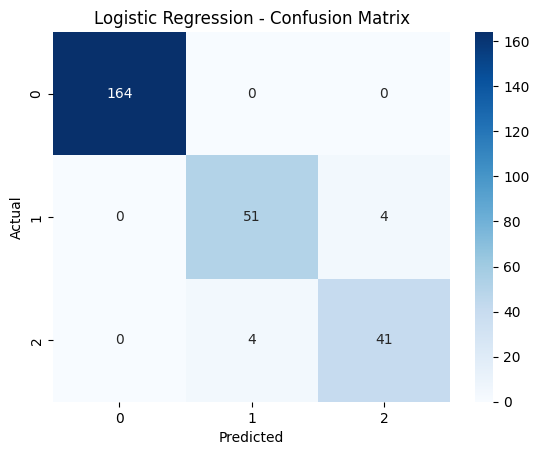


🔹 Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        45

    accuracy                           1.00       264
   macro avg       1.00      1.00      1.00       264
weighted avg       1.00      1.00      1.00       264



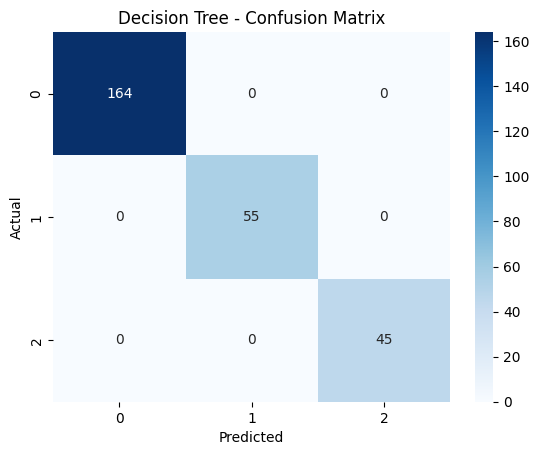


🔹 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        45

    accuracy                           1.00       264
   macro avg       1.00      1.00      1.00       264
weighted avg       1.00      1.00      1.00       264



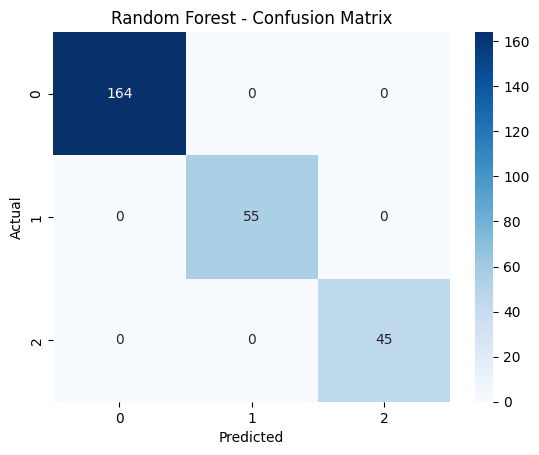


🔹 SVM
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       164
           1       0.00      0.00      0.00        55
           2       0.00      0.00      0.00        45

    accuracy                           0.62       264
   macro avg       0.21      0.33      0.26       264
weighted avg       0.39      0.62      0.48       264



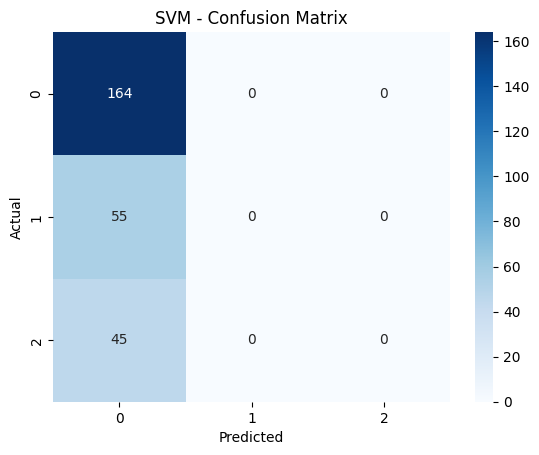


🔹 KNN
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       164
           1       0.49      0.42      0.45        55
           2       0.53      0.58      0.55        45

    accuracy                           0.63       264
   macro avg       0.57      0.57      0.57       264
weighted avg       0.63      0.63      0.63       264



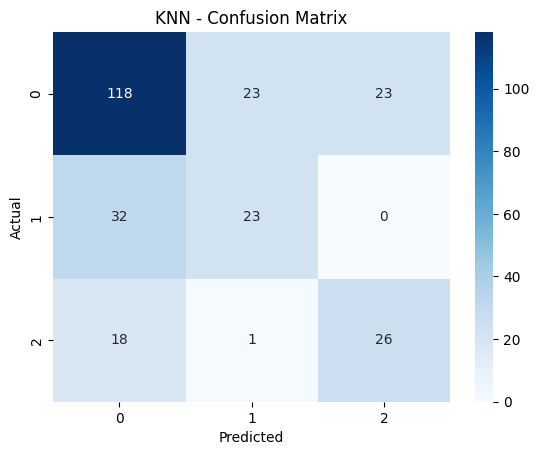


🔹 Naive Bayes
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       0.86      0.98      0.92        55
           2       0.97      0.80      0.88        45

    accuracy                           0.96       264
   macro avg       0.94      0.93      0.93       264
weighted avg       0.97      0.96      0.96       264



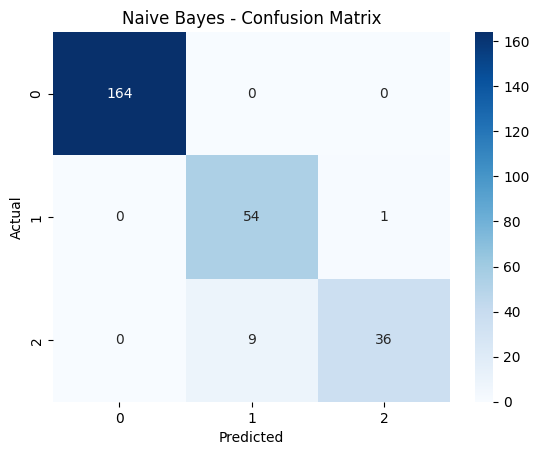

In [23]:
# Fit models and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n🔹 {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Thank you..pls upvote!!!